# GOA-UVa All-Sky Segmentation U-Net Model Usage Guide

## Set up environment

In [1]:
%%capture
%pip install tensorflow==2.15.1
%pip install matplotlib
%pip install numpy

In [ ]:
%matplotlib inline
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

## Load model

In [ ]:
model_path = "goauva_allsky_segmentation_unet_model.h5"

In [ ]:
keras.backend.clear_session()
cloud_segmenter = keras.models.load_model(model_path)

## Run model

In [5]:
img_path = "images/image_1.jpg"

In [6]:
IMG_SIZE = (256, 256)
img = tf.io.read_file(img_path)
img = tf.image.decode_jpeg(img, channels=3)
shape = tf.shape(img)[0:2]
if shape[0] != shape[1]:
    s = tf.minimum(shape[0], shape[1])
    offset_h = (shape[0]-s)//2
    offset_w = (shape[1]-s)//2
    shape = (s, s)
    img = tf.image.crop_to_bounding_box(img, offset_h, offset_w, s, s)
img = tf.image.resize(img, IMG_SIZE, method="area")
img = tf.cast(img, tf.float32)

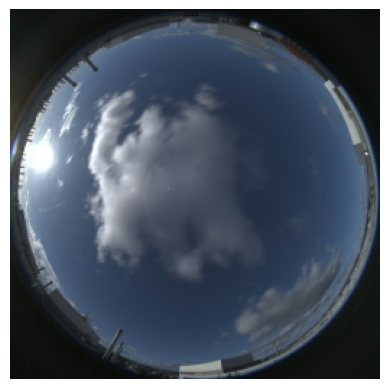

In [7]:
img_np = img.numpy()
if img_np.max() > 1.0:
    img_np = img_np / 255.0
plt.imshow(img_np)
plt.axis('off')
plt.show()

In [8]:
shape

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([512, 512], dtype=int32)>

In [9]:
batch = tf.expand_dims(img, axis=0)
mask_b = cloud_segmenter(batch)
mask_b = tf.argmax(mask_b, axis=-1, output_type=tf.int32)
mask = mask_b[0]
# Optional: Resize the mask to the size of the original image
# mask = tf.image.resize(tf.expand_dims(mask, axis=-1), shape, method="nearest")

In [10]:
COLORS = np.array([
    [0.0, 0.0, 0.0],      # 0 Not sky -> Black
    [0.0, 0.6, 1.0],      # 1 Cloud-free -> Blue
    [1.0, 1.0, 0.0],      # 2 Sun -> Yellow
    [1.0, 1.0, 1.0],      # 3 Cloud -> White
    [0.7, 0.7, 0.7],      # 4 Thin cloud -> Grey
])

cmap = ListedColormap(COLORS)

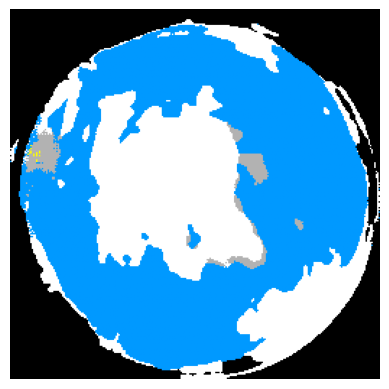

In [11]:
plt.imshow(mask, cmap=cmap, vmin=0, vmax=len(COLORS)-1)
plt.axis('off')
plt.show()